In [1]:
url = "https://www.superlife.co.nz/investment/age-steps/superlife-age-steps-strategy"


In [8]:
pip install pypalettes


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import polars as pl
import re 

# not 0-9 or . (for floats)
replace_non_digits = lambda x: re.sub(r'[^\d.]', '', x)
data = pd.concat((pd.read_html(url)[0], pd.read_html(url)[1]))
data['Age'] = data['Age'].apply(lambda x: replace_non_digits(str(x))).astype(int)
data['NZ Cash Fund'] = data['NZ Cash Fund'].apply(lambda x: replace_non_digits(str(x)) or None).astype(float)/100
data['SuperLife Income Fund'] = data['SuperLife Income Fund'].apply(lambda x: replace_non_digits(str(x)) or None).astype(float)/100
data['SuperLife High Growth Fund'] = data['SuperLife High Growth Fund'].apply(lambda x: replace_non_digits(str(x)) or None).astype(float)/100
data = data.iloc[1:]
data.set_index('Age', inplace=True, drop=True)
data.fillna(0, inplace=True)

# insert entry at age 0 with allocations from age 18
data.loc[0] = data.loc[18]
data.sort_index(inplace=True)

In [5]:
# from SIPO https://www.superlife.co.nz/files/LegalDocs/SLI-FundUpdates/2025-Dec/superlife%20invest%20fund%20update_nz_cash_fund.pdf
allocs = { # fund: (cash, inc, grw)
    "NZ Cash Fund":(1, 0, 0),
    "SuperLife Income Fund":(.2, .8, 0),
    "SuperLife High Growth Fund":(.01, 0, .99),
}

fund_allocations = pd.DataFrame(allocs).T.rename(columns={0:'Cash', 1:'Income', 2:'Growth'})

asset_allocations = pd.DataFrame(index=data.index, columns=['Cash', 'Income', 'Growth'])
# use the fund allocations to calculate the overall allocation to cash, income, and growth for each age step
for asset_class in fund_allocations.columns:
    alloc_vector = fund_allocations[asset_class].values
    asset_allocations[asset_class] = data @ alloc_vector
    

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_37088\4198693824.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_yticklabels([f"{int(tick*100)}%" for tick in ax[0].get_yticks()])
C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_37088\4198693824.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_yticklabels([f"{int(tick*100)}%" for tick in ax[1].get_yticks()])


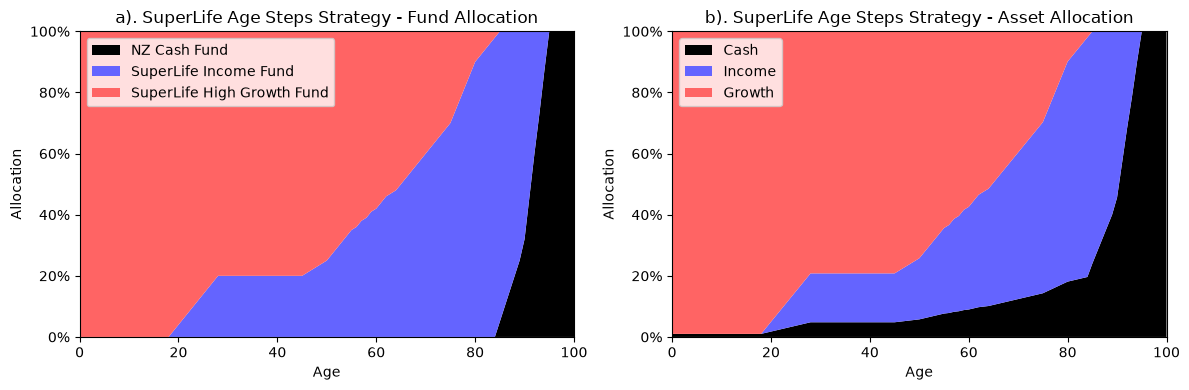

In [12]:
import matplotlib.pyplot as plt


fund_colours = {
    "NZ Cash Fund": "#000000",
    "SuperLife Income Fund": "#6464FF",
    "SuperLife High Growth Fund": "#ff6464",
}

allocation_colours = {
    "Cash": "#000000",
    "Income": "#6464FF",
    "Growth": "#ff6464",
}


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].stackplot(
    data.index,
    data["NZ Cash Fund"],
    data["SuperLife Income Fund"],
    data["SuperLife High Growth Fund"],
    labels=["NZ Cash Fund", "SuperLife Income Fund", "SuperLife High Growth Fund"],
    colors=[
        fund_colours["NZ Cash Fund"],
        fund_colours["SuperLife Income Fund"],
        fund_colours["SuperLife High Growth Fund"],
    ],
)
ax[0].set_title("a). SuperLife Age Steps Strategy - Fund Allocation")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Allocation")
ax[0].set_ylim(0, 1)
ax[0].set_yticklabels([f"{int(tick*100)}%" for tick in ax[0].get_yticks()])
ax[0].set_xlim(0, 100)
ax[0].legend(loc="upper left")

ax[1].stackplot(
    asset_allocations.index,
    asset_allocations["Cash"],
    asset_allocations["Income"],
    asset_allocations["Growth"],
    labels=["Cash", "Income", "Growth"],
    colors=[
        allocation_colours["Cash"],
        allocation_colours["Income"],
        allocation_colours["Growth"],
    ],
)
ax[1].set_title("b). SuperLife Age Steps Strategy - Asset Allocation")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Allocation")
ax[1].set_ylim(0, 1)
ax[1].set_yticklabels([f"{int(tick*100)}%" for tick in ax[1].get_yticks()])
ax[1].set_xlim(0, 100)
ax[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig("../age-steps.png", dpi=300)
plt.show()
